In [ ]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from src.dataset import generate_ou_process, create_windowed_dataset

Initializing Model...
Running Inference...


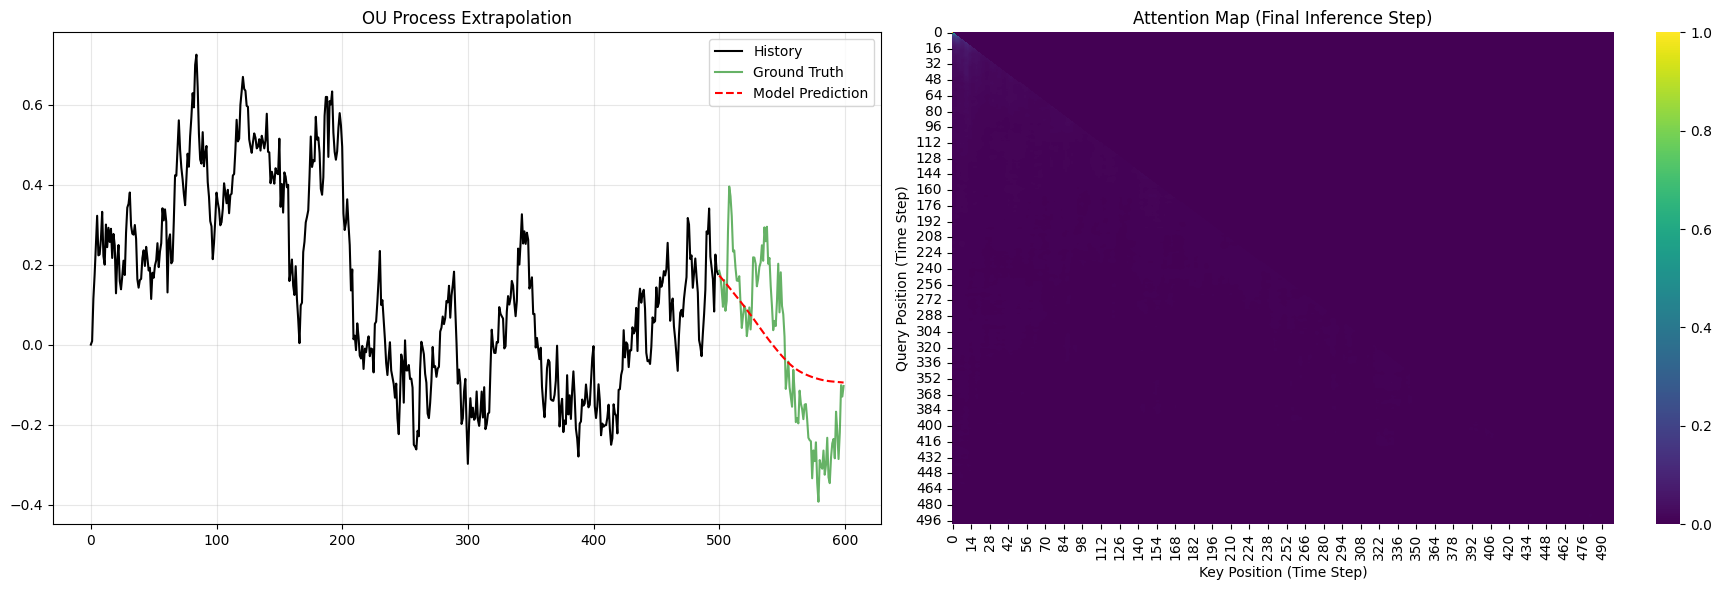

In [ ]:
def autoregressive_predict_with_map(model, history, future_steps=50, device='cpu'):
    model.eval() 
    current_seq = history.clone().to(device) # Shape: (1, 100, 1)
    predictions = []
    last_attention_map = None
    
    with torch.no_grad(): 
        for _ in range(future_steps):
            output, maps = model(current_seq)
            next_val = output[:, -1, 0:1]
            
            predictions.append(next_val.squeeze().item())
            
            # Capture the attention map from the LAST layer for this step
            # maps is a list of tensors. maps[-1] is the top layer.
            # Shape is usually (Batch, Seq_Len, Seq_Len) or (Batch, Heads, Seq, Seq)
            last_attention_map = maps[-1] 
            
            # Update sequence (use predicted mean E[X] as next observation)
            next_val_reshaped = next_val.unsqueeze(1) 
            current_seq = torch.cat([current_seq[:, 1:, :], next_val_reshaped], dim=1)
            
    return predictions, last_attention_map

# 3. Load Config & Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cfg = load_full_config()

print("Initializing Model...")
model = SimpleTransformer(**cfg['architecture'])

model_path = os.path.join('..', cfg['paths']['save_dir'], cfg['paths']['next_token_model_name'])
# Check if model exists, otherwise this will fail
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
else:
    print(f"Warning: Model not found at {model_path}. Please train first.")

# 4. Generate Test Data
phys_cfg = cfg['physics']
win_cfg = cfg['windowing']

raw_data = generate_ou_process(
    batch_size=1, 
    time_steps=win_cfg['input_len'] + win_cfg['output_len'] + 10, 
    **phys_cfg
)

X_test, Y_test = create_windowed_dataset(
    raw_data, 
    input_len=win_cfg['input_len'], 
    output_len=win_cfg['output_len'],
    stride=1
)

history = X_test[0:1].to(device)
ground_truth = Y_test[0:1].squeeze()

# 5. Run Prediction & Capture Map
print("Running Inference...")
preds, attn_map_tensor = autoregressive_predict_with_map(
    model, 
    history, 
    future_steps=win_cfg['output_len'], 
    device=device
)

# Process the attention map for plotting
attn_map_np = attn_map_tensor.squeeze().cpu().numpy()

# Check if we have multiple heads: (Heads, Seq, Seq) or (Seq, Seq)
has_multiple_heads = len(attn_map_np.shape) == 3

if has_multiple_heads:
    num_heads = attn_map_np.shape[0]
    seq_len = attn_map_np.shape[1]
else:
    num_heads = 1
    seq_len = attn_map_np.shape[0]
    attn_map_np = attn_map_np[np.newaxis, :, :]  # Add head dimension for uniform handling

# 6. Visualization
# Create figure with trajectory plot and attention head plots
if has_multiple_heads:
    fig = plt.figure(figsize=(18, 4 + 3 * num_heads))
    gs = fig.add_gridspec(2, max(2, num_heads), hspace=0.3, wspace=0.3)
    
    # Plot A: Trajectory (span first row)
    ax_traj = fig.add_subplot(gs[0, :])
else:
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    ax_traj = ax[0]

# Plot trajectory
t_hist = range(win_cfg['input_len'])
t_fut = range(win_cfg['input_len'], win_cfg['input_len'] + win_cfg['output_len'])

ax_traj.plot(t_hist, history.cpu().squeeze(), label='History', color='black')
ax_traj.plot(t_fut, ground_truth.cpu(), label='Ground Truth', color='green', alpha=0.6)
ax_traj.plot(t_fut, preds, label='Model Prediction', color='red', linestyle='--')
ax_traj.set_title("OU Process Extrapolation")
ax_traj.legend()
ax_traj.grid(True, alpha=0.3)

# Plot attention heads separately
if has_multiple_heads:
    for head_idx in range(num_heads):
        ax_attn = fig.add_subplot(gs[1, head_idx])
        sns.heatmap(attn_map_np[head_idx], ax=ax_attn, cmap="viridis", cbar=True)
        ax_attn.set_title(f"Attention Head {head_idx + 1}")
        ax_attn.set_xlabel("Key Position (Time Step)")
        ax_attn.set_ylabel("Query Position (Time Step)")
else:
    # Single head case
    sns.heatmap(attn_map_np[0], ax=ax[1], cmap="viridis")
    ax[1].set_title("Attention Map (Final Inference Step)")
    ax[1].set_xlabel("Key Position (Time Step)")
    ax[1].set_ylabel("Query Position (Time Step)")

plt.tight_layout()
plt.show()